# NBA All-Star Predictor

Binary classification analysis predicting NBA All-Star selections from per-game player statistics (1980–2026).

**Research Question:** Can we predict All-Star selections from box score statistics alone — and if so, which stats matter most?

**Dataset:** Basketball Reference via Kaggle — 33,000+ player seasons across 75+ years  
**Models:** Logistic Regression, Random Forest  
**Key challenge:** Severe class imbalance — only 6.47% of player-seasons are All-Star selections

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the primary dataset: per-game player statistics. Each row represents one player's stats for a single season.

In [2]:
df = pd.read_csv('../NBA-Players/Player Per Game.csv')
print(df.shape)
print(df.head())
print(df.info())

(33339, 32)
   season   lg            player  player_id   age team pos   g    gs  \
0    2026  NBA  Precious Achiuwa  achiupr01  26.0  SAC   C  73  57.0   
1    2026  NBA      Steven Adams  adamsst01  32.0  HOU   C  32  11.0   
2    2026  NBA       Bam Adebayo  adebaba01  28.0  MIA   C  73  73.0   
3    2026  NBA      Ochai Agbaji  agbajoc01  25.0  2TM  SG  62  13.0   
4    2026  NBA      Ochai Agbaji  agbajoc01  25.0  TOR  SG  42  13.0   

   mp_per_game  ...  ft_percent  orb_per_game  drb_per_game  trb_per_game  \
0         23.9  ...       0.554           2.4           4.3           6.7   
1         22.8  ...       0.580           4.5           4.1           8.6   
2         32.4  ...       0.778           2.0           8.0          10.0   
3         15.7  ...       0.837           0.7           1.5           2.3   
4         15.5  ...       0.862           0.8           1.5           2.3   

   ast_per_game  stl_per_game  blk_per_game  tov_per_game  pf_per_game  \
0           1.4   

## 2. Exploratory Data Analysis

Before modelling, we need to understand the data's structure, missing values, and statistical properties.

Key things to check:
- Null counts per column (3-point stats will be null pre-1979 — expected)
- Duplicate rows for traded players (a player traded mid-season appears once per team)
- Season range to understand the historical scope
- Basic distributional properties of key stats

In [3]:
# Check nulls
print(df.isnull().sum())

# Check duplicate player-seasons (traded players)
print(df[df['team'] == 'TOT'].shape)  # TOT = total, these are the combined rows

# Basic stats distribution
print(df[['pts_per_game', 'ast_per_game', 'trb_per_game', 
          'stl_per_game', 'blk_per_game']].describe())

# Season range
print(df['season'].min(), df['season'].max())

season               0
lg                   0
player               0
player_id            0
age                 20
team                 0
pos               1197
g                    0
gs                8178
mp_per_game       1083
fg_per_game          0
fga_per_game         0
fg_percent         164
x3p_per_game      6352
x3pa_per_game     6353
x3p_percent      10625
x2p_per_game      6352
x2pa_per_game     6352
x2p_percent       6590
e_fg_percent      6497
ft_per_game          0
fta_per_game         0
ft_percent        1365
orb_per_game      4646
drb_per_game      4646
trb_per_game       894
ast_per_game         0
stl_per_game      5602
blk_per_game      5600
tov_per_game      5636
pf_per_game          1
pts_per_game         0
dtype: int64
(0, 32)
       pts_per_game  ast_per_game  trb_per_game  stl_per_game  blk_per_game
count  33339.000000  33339.000000  32445.000000  27737.000000  27739.000000
mean       8.353040      1.880038      3.719871      0.662379      0.402596
std        6.10

### 2.1 Stat Distributions

All six core stats are right-skewed — the majority of NBA players are role players and bench players clustered at low values, with elite players forming the long right tail. This is the population we expect All-Stars to live in.

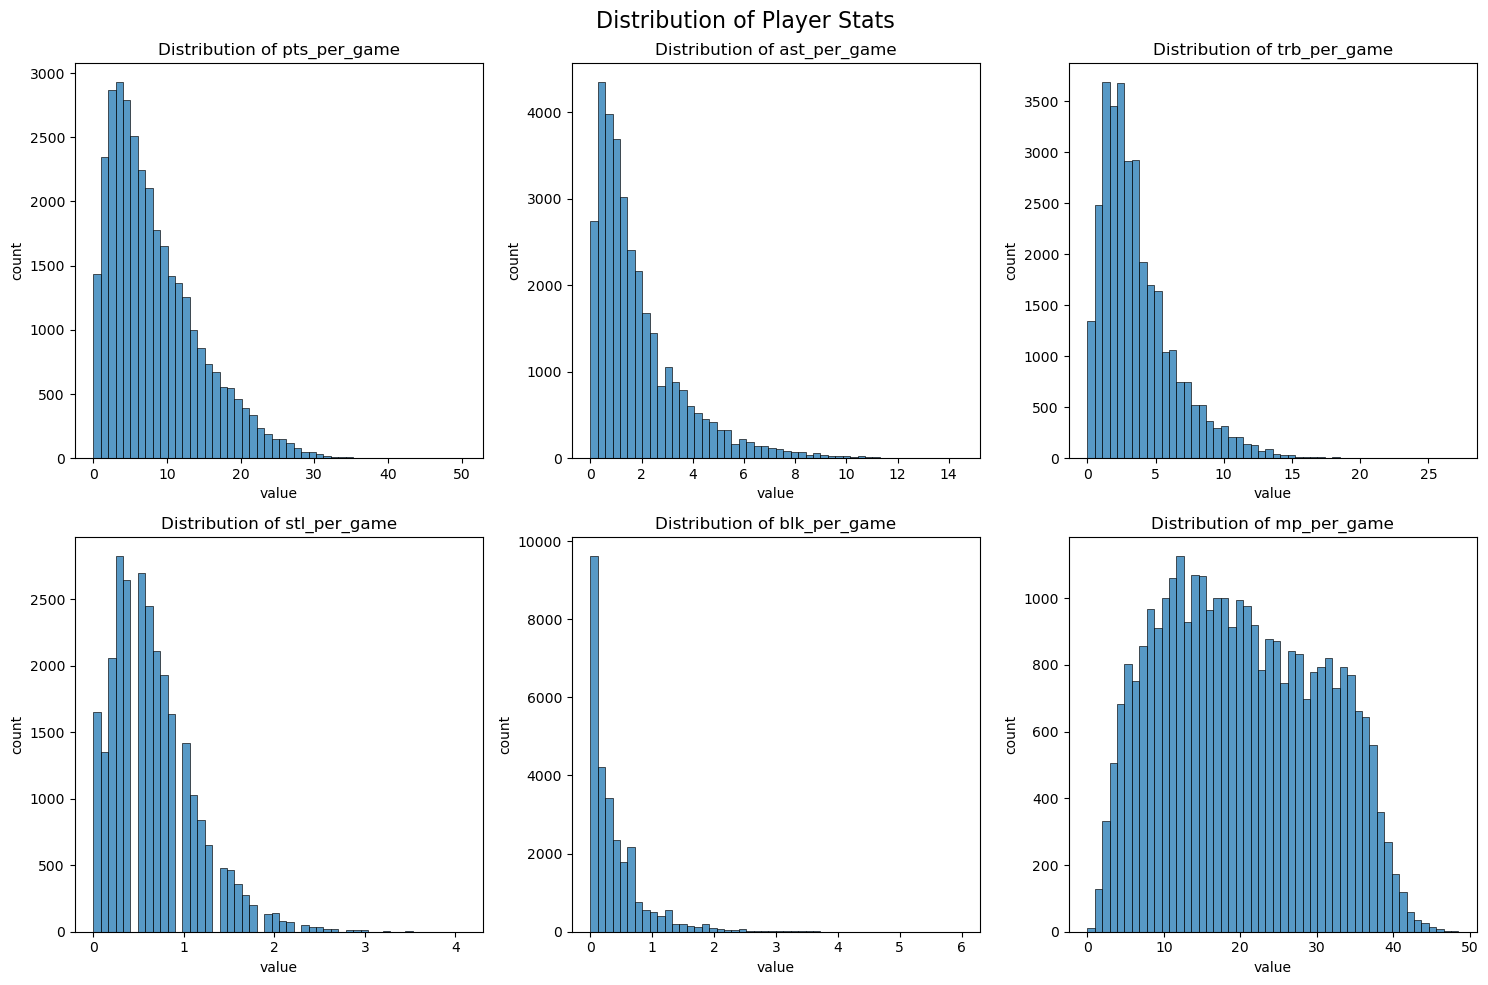

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\nikhi\\Downloads\\NBA-player-analysis\\Notebooks\\Results\\player_stats_distribution.png'

<Figure size 640x480 with 0 Axes>

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
stats = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game', 'blk_per_game', 'mp_per_game']
for ax, stat in zip(axs.flatten(), stats):
    sns.histplot(df[stat], bins=50, ax=ax)
    ax.set_title(f'Distribution of {stat}')
    ax.set_xlabel('value')
    ax.set_ylabel('count')

plt.suptitle('Distribution of Player Stats', fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig('Results/player_stats_distribution.png')

## 3. Merging All-Star Labels

We load the All-Star selections dataset and merge it with the player stats on `player_id` and `season`. This creates a binary target variable: 1 for All-Star selections, 0 for all other player-seasons.

A left join ensures we retain all player-seasons, with non-All-Stars filled as 0.

In [ ]:
allstar = pd.read_csv('../NBA-Players/All-Star Selections.csv')
print(allstar.head())
print(allstar.shape)
print(allstar.columns.tolist())

            player  player_id        team  season   lg  replaced
0   Scottie Barnes  barnesc01  Team Stars    2026  NBA     False
1     Devin Booker  bookede01  Team Stars    2026  NBA     False
2  Cade Cunningham  cunnica01  Team Stars    2026  NBA     False
3      Jalen Duren  durenja01  Team Stars    2026  NBA     False
4  Anthony Edwards  edwaran01  Team Stars    2026  NBA     False
(2058, 6)
['player', 'player_id', 'team', 'season', 'lg', 'replaced']


In [ ]:
# Create All-Star label
allstar['is_allstar'] = 1

# Merge with main dataframe
df_merged = df.merge(
    allstar[['player_id', 'season', 'is_allstar']], 
    on=['player_id', 'season'], 
    how='left'
)

# Fill non All-Stars with 0
df_merged['is_allstar'] = df_merged['is_allstar'].fillna(0).astype(int)

# Check balance
print(df_merged['is_allstar'].value_counts())
print(f"\nAll-Star rate: {df_merged['is_allstar'].mean():.3%}")

# Sanity check — LeBron James should appear as All-Star across multiple seasons
print(df_merged[df_merged['player'] == 'LeBron James'][['season', 'pts_per_game', 'ast_per_game', 'trb_per_game', 'is_allstar']])

is_allstar
0    31181
1     2158
Name: count, dtype: int64

All-Star rate: 6.473%
       season  pts_per_game  ast_per_game  trb_per_game  is_allstar
308      2026          20.9           7.2           6.1           1
1032     2025          24.4           8.2           7.8           1
1793     2024          25.7           8.3           7.3           1
2509     2023          28.9           6.8           8.3           1
3249     2022          30.3           6.2           8.2           1
4022     2021          25.0           7.8           7.7           1
4718     2020          25.3          10.2           7.8           1
5382     2019          27.4           8.3           8.5           1
6061     2018          27.5           9.1           8.6           1
6692     2017          26.4           8.7           8.6           1
7281     2016          25.3           6.8           7.4           1
7883     2015          25.3           7.4           6.0           1
8541     2014          27.1       

## 4. All-Star vs Non All-Star Comparison

### 4.1 Points Bias Hypothesis

A natural hypothesis is that All-Star selection is primarily driven by scoring — fans and coaches reward high-volume scorers. We test this by examining correlations between each stat and All-Star status, and comparing group means.

**Hypothesis:** Points per game will be the strongest single predictor of All-Star selection.

In [ ]:
# Compare All-Star vs non All-Star average stats
comparison = df_merged.groupby('is_allstar')[
    ['pts_per_game', 'ast_per_game', 'trb_per_game', 
     'stl_per_game', 'blk_per_game', 'mp_per_game']
].mean().round(2)

print(comparison)

# Correlation of stats with All-Star status
correlations = df_merged[
    ['pts_per_game', 'ast_per_game', 'trb_per_game',
     'stl_per_game', 'blk_per_game', 'mp_per_game', 'is_allstar']
].corr()['is_allstar'].sort_values(ascending=False)

print("\nCorrelation with All-Star status:")
print(correlations)

            pts_per_game  ast_per_game  trb_per_game  stl_per_game  \
is_allstar                                                           
0                   7.49          1.71          3.43          0.63   
1                  20.89          4.35          7.86          1.31   

            blk_per_game  mp_per_game  
is_allstar                             
0                   0.37        18.99  
1                   0.91        36.13  

Correlation with All-Star status:
is_allstar      1.000000
pts_per_game    0.539792
mp_per_game     0.417888
trb_per_game    0.393879
ast_per_game    0.365263
stl_per_game    0.322878
blk_per_game    0.242212
Name: is_allstar, dtype: float64


**Findings:**
- All-Stars average nearly 3x the points of non All-Stars (20.9 vs 7.5 ppg)
- Points correlation (0.54) is the strongest single predictor — hypothesis partially confirmed
- However, minutes per game (0.42) is nearly as strong, suggesting the model may partially learn playing time as a proxy for All-Star candidacy — starters accumulate the stats needed for selection
- The full dataset includes bench players and end-of-roster players who pull group averages down significantly

**Limitation:** Including all player-seasons (including players averaging 5 minutes per game) makes the All-Star group look more separated than it actually is among legitimate candidates.

### 4.2 Distribution Comparison: All-Stars vs Non All-Stars

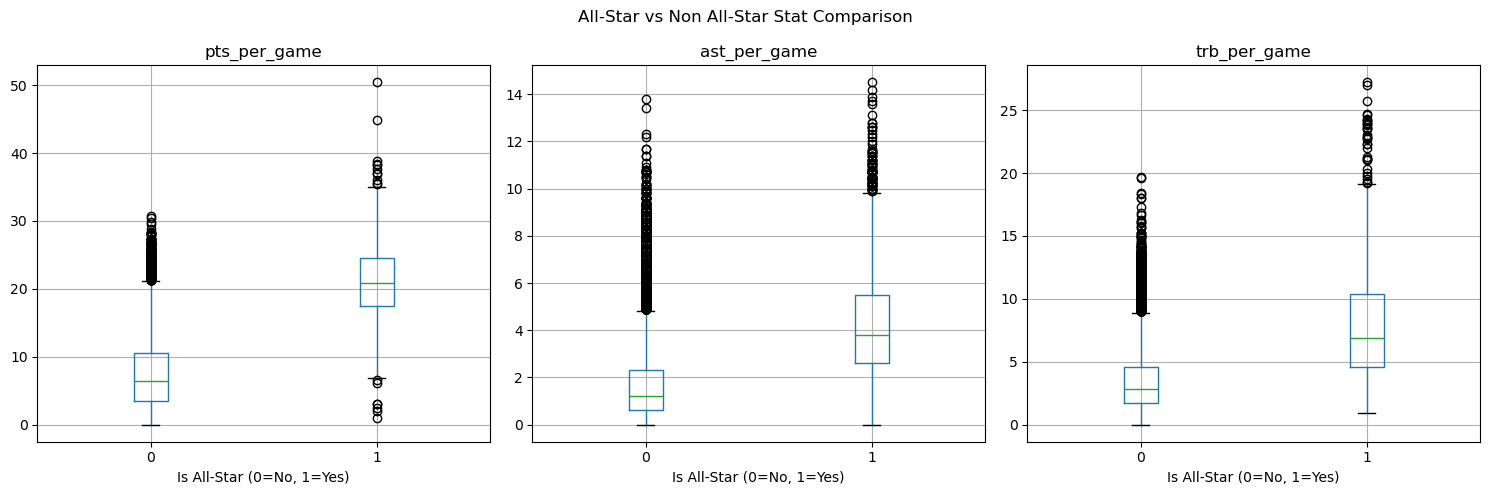

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, stat in zip(axes, ['pts_per_game', 'ast_per_game', 'trb_per_game']):
    df_merged.boxplot(column=stat, by='is_allstar', ax=ax)
    ax.set_title(stat)
    ax.set_xlabel('Is All-Star (0=No, 1=Yes)')

plt.suptitle('All-Star vs Non All-Star Stat Comparison')
plt.tight_layout()
plt.savefig('Results/allstar_comparison.png', dpi=150)
plt.show()

**Key observation:** The outliers in the non All-Star group (0) are analytically interesting. There are players with 30+ ppg, 20+ rpg, and 13+ apg who were never selected as All-Stars. This points to non-statistical factors influencing selection — fan voting bias, team market size, player popularity, and team performance all play a role that box scores cannot capture.

This sets a hard ceiling on any stat-only model's performance.

## 5. Modelling

### 5.1 Feature Engineering and Train/Test Split

**Design decisions:**
- Filter to post-1980 seasons only — steals, blocks, and 3-point stats are largely absent before this, making pre-1980 data structurally different
- Use `class_weight='balanced'` in both models to handle the 6.47% positive class rate — without this, models simply predict 0 for everyone and achieve 93.5% accuracy while being completely useless
- Stratified train/test split to preserve the All-Star rate in both sets
- **Primary evaluation metric: ROC-AUC**, not accuracy — accuracy is misleading under class imbalance

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Feature engineering
features = ['pts_per_game', 'ast_per_game', 'trb_per_game', 
            'stl_per_game', 'blk_per_game', 'mp_per_game',
            'fg_percent', 'ft_percent']

# Filter to post-1980 only (stats more complete, modern era)
df_model = df_merged[df_merged['season'] >= 1980].copy()

# Drop rows where any feature is null
df_model = df_model.dropna(subset=features)

X = df_model[features]
y = df_model['is_allstar']

# Train test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"All-Star rate in train: {y_train.mean():.3%}")
print(f"All-Star rate in test: {y_test.mean():.3%}")

Training set: (19328, 8)
Test set: (4833, 8)
All-Star rate in train: 5.065%
All-Star rate in test: 5.069%


### 5.2 Model Training and Evaluation

Two classifiers trained with balanced class weights:
- **Logistic Regression** — linear baseline, interpretable coefficients
- **Random Forest** — ensemble method, captures non-linear relationships, provides feature importance

In [ ]:
# Model 1 — Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Model 2 — Random Forest
rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# Evaluate both
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.3f}")

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      4588
           1       0.36      0.96      0.52       245

    accuracy                           0.91      4833
   macro avg       0.68      0.93      0.74      4833
weighted avg       0.96      0.91      0.93      4833

ROC-AUC: 0.977

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4588
           1       0.77      0.54      0.63       245

    accuracy                           0.97      4833
   macro avg       0.87      0.77      0.81      4833
weighted avg       0.97      0.97      0.97      4833

ROC-AUC: 0.974


**Initial results:**
- Both models achieve ROC-AUC ~0.975 — the underlying ranking of players by All-Star likelihood is strong
- **Logistic Regression:** High recall (0.96) but low precision (0.36) — catches nearly all All-Stars but flags too many false positives
- **Random Forest:** Higher precision (0.77) but lower recall (0.54) — more conservative, misses more actual All-Stars

The difference is not model quality — it is where the default decision threshold sits. Both models have nearly identical ranking ability.

### 5.3 Feature Importance

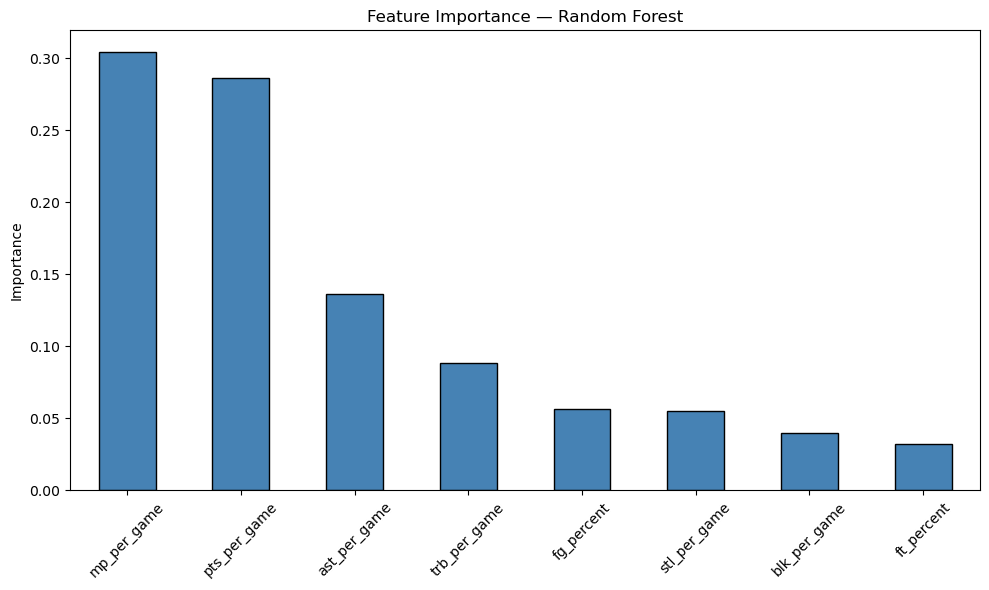

mp_per_game     0.304238
pts_per_game    0.286557
ast_per_game    0.136544
trb_per_game    0.088505
fg_percent      0.056587
stl_per_game    0.055463
blk_per_game    0.039580
ft_percent      0.032526
dtype: float64


In [ ]:
# Random Forest feature importance
importances = pd.Series(
    rf.feature_importances_, 
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Results/feature_importance.png', dpi=150)
plt.show()

print(importances)

**Finding:** Minutes per game (0.30) narrowly edges points per game (0.29) as the top feature. Together they account for ~59% of the model's decisions.

This partially confirms the points bias hypothesis but reveals a more nuanced picture: **the model is learning playing time as a proxy for All-Star candidacy**. Starters with high minutes naturally accumulate the counting stats that lead to All-Star selection. A bench player averaging 12 minutes cannot physically produce All-Star numbers regardless of efficiency.

Blocks, FT%, and steals contribute minimally — All-Star selection rewards volume scorers and playmakers, not defensive specialists.

### 5.4 Confusion Matrices

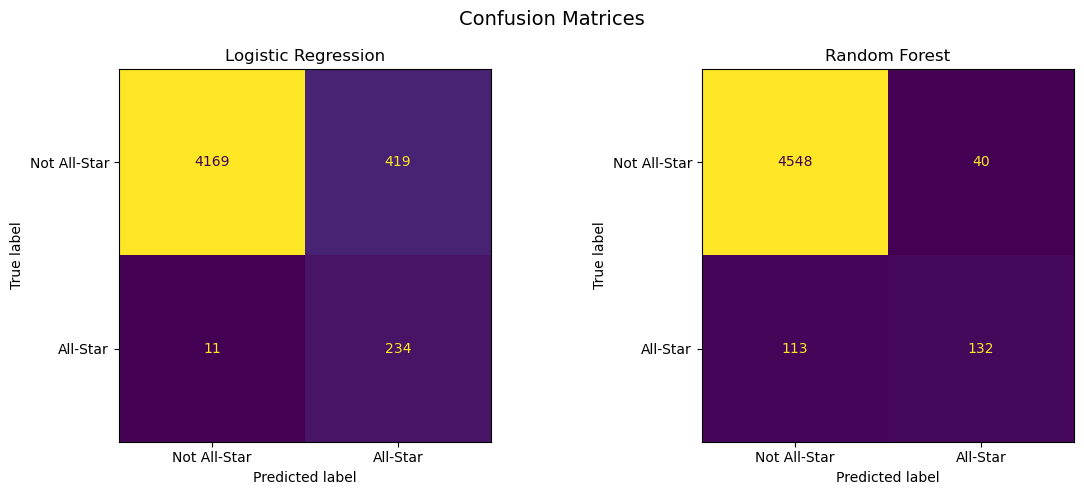

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes, 
    [lr_preds, rf_preds], 
    ['Logistic Regression', 'Random Forest']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, ax=ax, colorbar=False,
        display_labels=['Not All-Star', 'All-Star']
    )
    ax.set_title(title)

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('Results/confusion_matrices.png', dpi=150)
plt.show()

### 5.5 Threshold Tuning

Both models use a default 0.5 decision threshold, which is not optimal under class imbalance. We find the threshold that maximises F1 score — the harmonic mean of precision and recall — to achieve the best balance between catching All-Stars and avoiding false alarms.

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Find optimal threshold for each model
for name, proba in [('Logistic Regression', lr_proba), ('Random Forest', rf_proba)]:
    precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
    
    # F1 score at each threshold
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    print(f"\n=== {name} ===")
    print(f"Optimal threshold: {best_threshold:.3f}")
    print(f"Best F1: {f1_scores[best_idx]:.3f}")
    
    # Apply new threshold
    new_preds = (proba >= best_threshold).astype(int)
    print(classification_report(y_test, new_preds))


=== Logistic Regression ===
Optimal threshold: 0.902
Best F1: 0.670
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4588
           1       0.63      0.71      0.67       245

    accuracy                           0.96      4833
   macro avg       0.81      0.85      0.83      4833
weighted avg       0.97      0.96      0.97      4833


=== Random Forest ===
Optimal threshold: 0.340
Best F1: 0.675
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4588
           1       0.66      0.69      0.67       245

    accuracy                           0.97      4833
   macro avg       0.82      0.84      0.83      4833
weighted avg       0.97      0.97      0.97      4833



## 6. Conclusion

| Model | ROC-AUC | F1 (default threshold) | F1 (tuned threshold) |
|-------|---------|------------------------|----------------------|
| Logistic Regression | 0.977 | 0.52 | 0.67 |
| Random Forest | 0.974 | 0.63 | 0.67 |

Optimal thresholds: LR = 0.902, RF = 0.340

**Both models converge to F1 = 0.67 after threshold tuning.** This convergence suggests we have hit the ceiling of what per-game statistics alone can predict.

**Why the ceiling exists:** All-Star selection is not purely meritocratic. Fan voting, team market size, player popularity, team win percentage, and media narrative all influence selections in ways that box scores cannot capture. The players in the non All-Star outlier group — those with elite stats who were never selected — are evidence of this gap.

**Next steps to push past this ceiling:**
- Incorporate advanced metrics from `Advanced.csv` (PER, Win Shares, VORP, BPM)
- Add team win percentage as a feature — players on winning teams get more All-Star consideration
- Experiment with XGBoost for potentially better ensemble performance
- Consider position-specific models — the stat profile of an All-Star centre differs fundamentally from an All-Star point guard